In [ ]:
# Objective: Understand the relationship between product categories and their best-seller status.
# 1. Crosstab Analysis:

# Create a crosstab between the product category and the isBestSeller status.

# Are there categories where being a best-seller is more prevalent?

# Hint: one option is to calculate the proportion of best-sellers for each category and then 
# sort the categories based on this proportion in descending order.

# Answer: Since p < 0.05, there is a statistically significant association between product category and best-seller status. 
# The distribution of best-sellers is not independent of product category. However, Cramér's V (0.122) indicates that the association 
# is weak. This suggests that while product category has a statistically significant relationship with whether a product is a best-seller, 
# the effect size is relatively small, meaning category alone is not a strong predictor of best-seller status.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [3]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv.zip", compression="zip")

In [4]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
crosstab_result = pd.crosstab(df['isBestSeller'], df['category'])

crosstab_result

category,3D Printers,3D Printing & Scanning,Abrasive & Finishing Products,Action Cameras,Adapters,Agricultural Equipment & Supplies,Alexa Built-In Devices,Art & Craft Supplies,Arts & Crafts,Baby,...,Uninterruptible Power Supply Units & Accessories,Vacuums & Floorcare,Vases,"Water Coolers, Filters & Cartridges",Wearable Technology,Wind Instruments,Window Treatments,Women,Women's Sports & Outdoor Shoes,eBook Readers & Accessories
isBestSeller,,,,,,,,,,,,,,,,,,,,,
False,247,4065,245,1696,251,8421,106,253,9319,14709,...,3652,6919,250,186,8876,243,234,17559,1939,246
True,1,2,5,1,3,109,1,5,230,341,...,1,26,0,1,30,7,5,213,20,0


In [7]:
proportions = crosstab_result.div(crosstab_result.sum(axis=0), axis=1)
best_seller_proportions = proportions.loc[True]

In [13]:
best_seller_proportions = best_seller_proportions.sort_values(ascending=False)
best_seller_proportions.head(20)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
Professional Medical Supplies     0.027344
PC & Video Games                  0.025466
Bakeware                          0.025105
Material Handling Products        0.025000
Bedding Accessories               0.024390
Tableware                         0.024096
Arts & Crafts                     0.024086
Baby                              0.022658
Lighting                          0.022556
Window Treatments                 0.020921
Name: True, dtype: float64

In [ ]:
# 2. Statistical Tests:

# Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
# Compute Cramér's V to understand the strength of association between best-seller status and category.


In [33]:
from scipy.stats import chi2_contingency


In [17]:
chi2_statistic, chi2_p_value, _, _ = chi2_contingency(crosstab_result)

chi2_statistic, chi2_p_value

(np.float64(36540.20270061387), np.float64(0.0))

In [18]:
from scipy.stats.contingency import association

# Computing the association between variables in 'crosstab_result' using the "cramer" method
association(crosstab_result, method="cramer")

0.1222829439760564

In [ ]:
# 3. Visualizations:

# Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

In [19]:
crosstab_result.T

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [22]:
top20 = df["category"].value_counts().head(20).index
top20

Index(['Sports & Outdoors', 'Beauty', 'Handmade Clothing, Shoes & Accessories',
       'Bath & Body', 'Birthday Gifts', 'Manicure & Pedicure Products',
       'Skin Care', 'Make-up', 'Hair Care', 'Fragrances', 'Handmade Gifts',
       'Handmade Home Décor', 'Luggage and travel gear', 'Handmade Jewellery',
       'Handmade Artwork', 'Women', 'Handmade Home & Kitchen Products',
       'Handmade Kitchen & Dining', 'Men', 'Baby'],
      dtype='object', name='category')

In [29]:
df_top20 = df[df["category"].isin(top20)]

In [31]:
crosstab_top20 = pd.crosstab(
    df_top20["category"],
    df_top20["isBestSeller"]
)

<Axes: xlabel='category'>

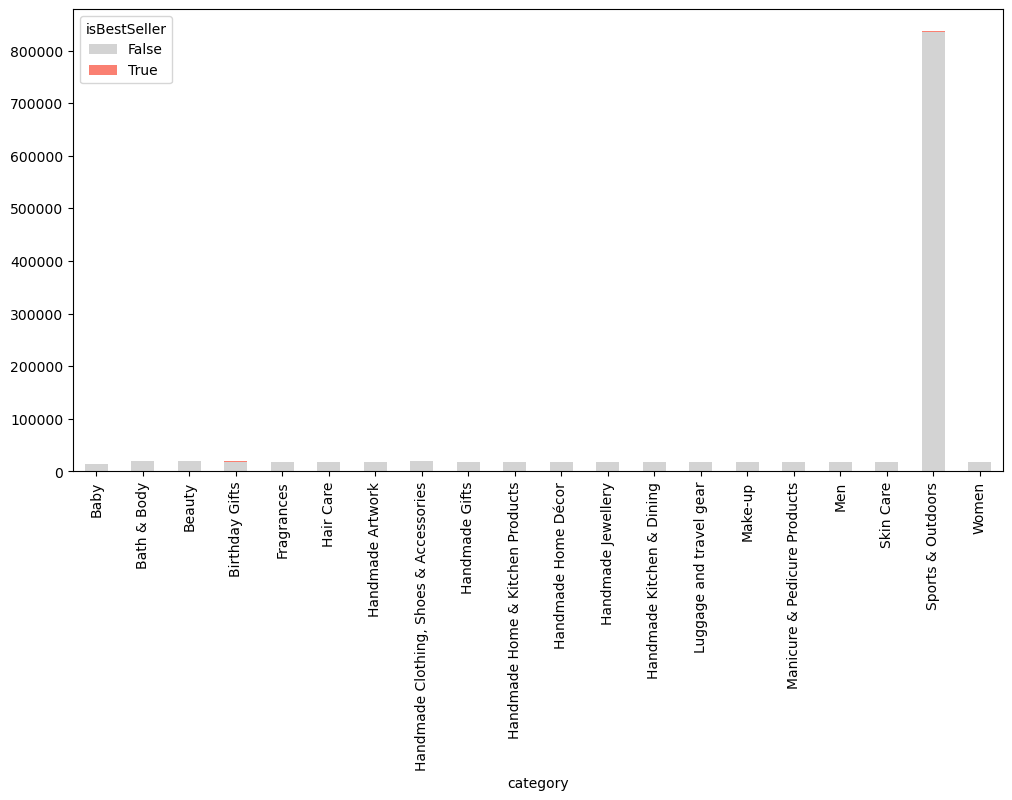

In [32]:
crosstab_top20.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["lightgray", "salmon"]
)

In [50]:
proportions = proportions.T

In [51]:
proportions = proportions.sort_values(by=True, ascending=False)
proportions_top20 = proportions.head(20)

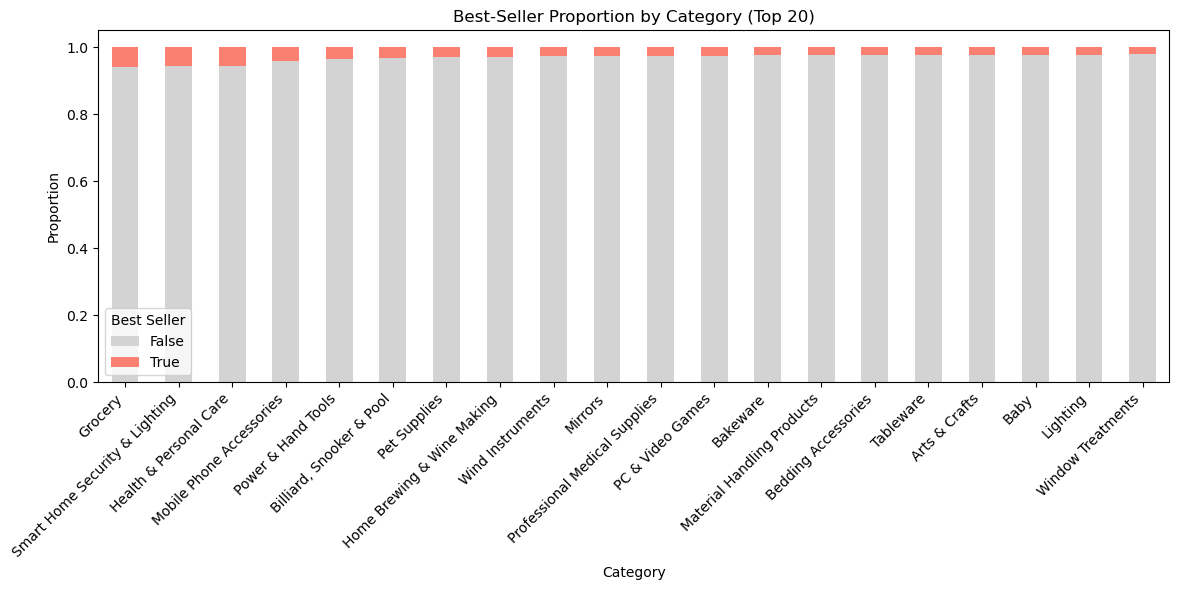

In [52]:
proportions_top20.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["lightgray", "salmon"]
)

plt.title("Best-Seller Proportion by Category (Top 20)")
plt.xlabel("Category")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Best Seller")
plt.tight_layout()
plt.show()

In [ ]:
# 0. Preliminary Step: Remove outliers in product prices.

# For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile 
# minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. 
# The next steps will be done with the dataframe without outliers.

# Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.

In [57]:
def remove_tukey_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

df_no_out = remove_tukey_outliers(df, "price")

In [66]:
df_no_out.sort_values(by="price").tail()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
2133173,2474089,B07MZ9LLCC,Google Pixel 3 64GB - Just Black - Unlocked (R...,4.1,41,99.99,False,0,Mobile Phones & Smartphones
2133182,2474098,B09NLK3QKF,"UMIDIGI Bison X10S Rugged Phone,6150mAh Batter...",3.7,337,99.99,False,0,Mobile Phones & Smartphones
2133281,2474202,B071F9HN3X,Nokia 5 UK-SIM Free Smartphone - Copper,4.2,423,99.99,False,0,Mobile Phones & Smartphones
2133094,2474010,B012C47W4S,Samsung Galaxy J5 Smartphone,4.2,449,99.99,False,0,Mobile Phones & Smartphones
751372,810373,B0BWS7P5FQ,Gear4music Guitar Hard Case for Full Size Elec...,0.0,0,99.99,False,0,Guitars & Gear


In [ ]:
# 1. Violin Plots:

# Use a violin plot to visualize the distribution of price across different product categories. 
# Filter out the top 20 categories based on count for better visualization.
# Which product category tends to have the highest median price? Don't filter here by top categories. 

In [68]:
median_prices = df_no_out.groupby("category")["price"].median().sort_values(ascending=False)

median_prices.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

In [ ]:
# Desktop PCs tend to have the highest median price.

In [73]:
top20violin = df_no_out["category"].value_counts().head(20).index

df_top20 = df_no_out[df_no_out["category"].isin(top20)]

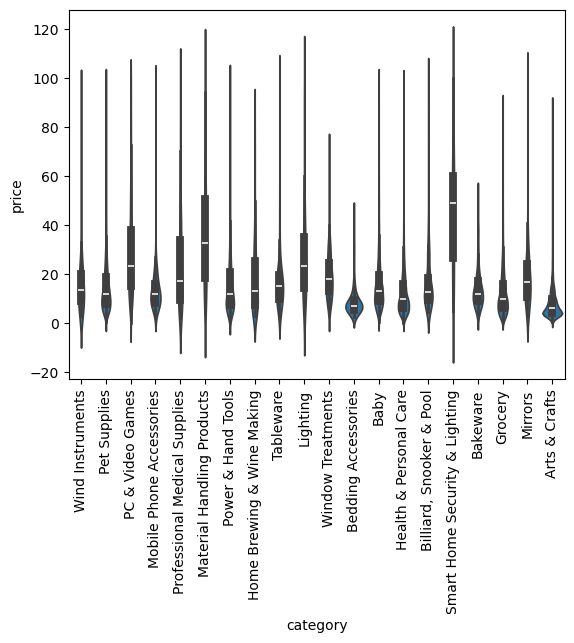

In [74]:
sns.violinplot(
    data=df_top20,
    x="category",
    y="price"
)

plt.xticks(rotation=90)
plt.show()

In [ ]:
# 2. Bar Charts:

# Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
# Which product category commands the highest average price? Don't filter here by top categories.

In [76]:
top10cat = df_no_out["category"].value_counts().head(10).index

df_top10 = df_no_out[df_no_out["category"].isin(top10cat)]

In [77]:
avg_price_top10 = (
    df_top10
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

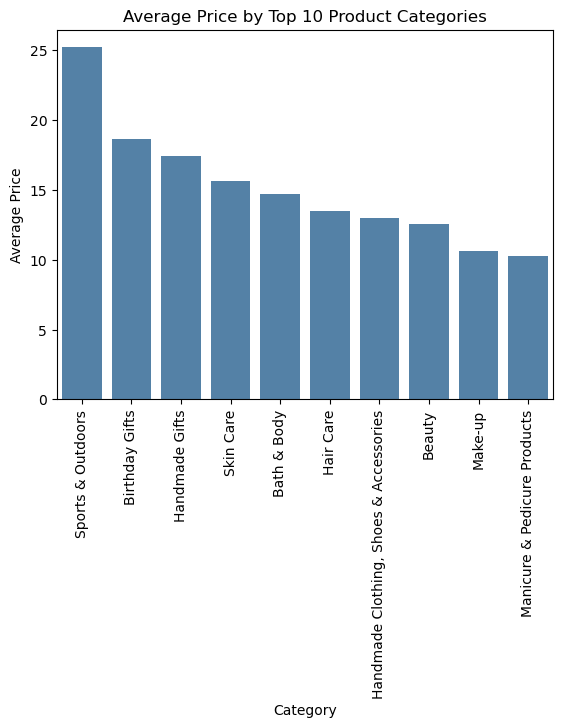

In [78]:
sns.barplot(
    x=avg_price_top10.index,
    y=avg_price_top10.values,
    color="steelblue"
)

plt.xticks(rotation=90)
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.title("Average Price by Top 10 Product Categories")
plt.show()

In [79]:
avg_price_all = (
    df_no_out
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_all.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

In [ ]:
# Motherboards command the highest average price.

In [ ]:
# 3. Box Plots:

# Visualize the distribution of product ratings based on their category using side-by-side box plots. 
# Filter out the top 10 categories based on count for better visualization.
# Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

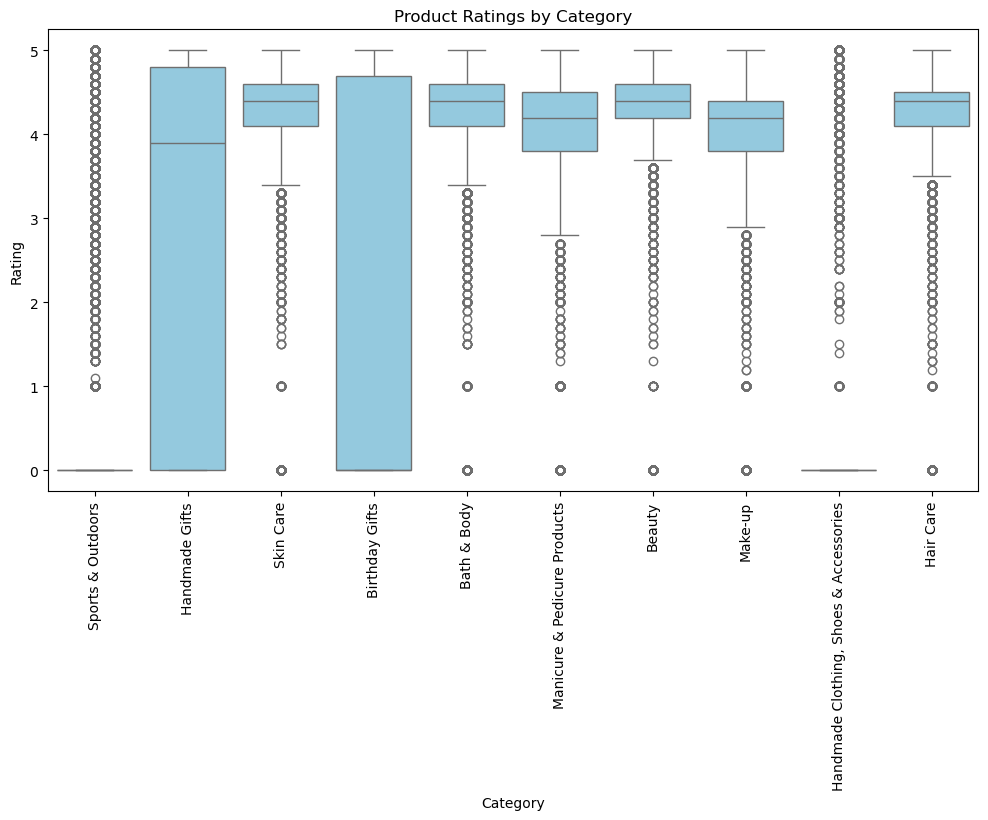

In [80]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_top10,
    x="category",
    y="stars",
    color="skyblue"
)

plt.xticks(rotation=90)
plt.xlabel("Category")
plt.ylabel("Rating")
plt.title("Product Ratings by Category")
plt.show()

In [81]:
median_ratings = (
    df_no_out.groupby("category")["stars"]
      .median()
      .sort_values(ascending=False)
)

median_ratings.head(10)

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64

In [ ]:
# Computer Memory category tend to receive the highest median rating from customers.

In [ ]:
# Objective: Analyze how product ratings (stars) correlate with product prices.

# 1. Correlation Coefficients:

# Calculate the correlation coefficient between price and stars.
# Is there a significant correlation between product price and its rating?

In [83]:
from scipy.stats import pearsonr

r, p = pearsonr(df["price"], df["stars"])

print("Correlation:", r)
print("p-value:", p)

Correlation: -0.1249067326214852
p-value: 0.0


In [ ]:
# There is a statistically significant but very weak negative correlation between product price and customer ratings 
# (r = -0.125, p < 0.001). This suggests that more expensive products tend to receive slightly lower ratings on average, 
# but the relationship is weak and unlikely to be of practical importance.

In [ ]:
# 2. Visualizations:

# Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
# Use a correlation heatmap to visualize correlations between all numerical variables.

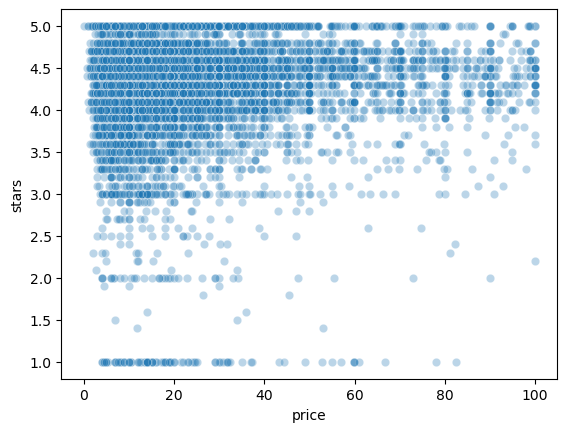

In [89]:
df_rated = df_no_out[df_no_out["stars"] > 0]

sample = df_rated.sample(10000, random_state=42)

sns.scatterplot(
    data=sample,
    x="price",
    y="stars",
    alpha=0.3
)

plt.show()

<Axes: >

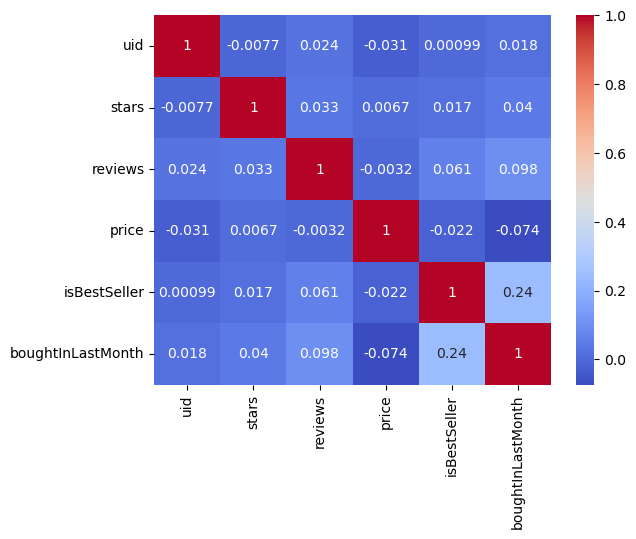

In [90]:
corr = df_rated.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

In [91]:
# Most products, regardless of price, receive ratings between 4 and 5 stars. While there is a statistically significant weak negative 
# relationship between price and rating (r = -0.125), the scatter plot shows substantial variability at every price level. 
# This suggests that product price has little practical influence on customer ratings, and other factors are likely more important 
# in determining customer satisfaction.


# The heatmap indicates that most numerical variables are only weakly correlated. 
# The only relationship that stands out is the weak positive correlation (0.24) between being a best seller and being bought 
# in the last month, which is expected because best-selling products are generally purchased more frequently.

In [ ]:
# Business-Centered Summary

###- Product prices vary significantly across categories.
###- "Smart Home Security & Lighting" has the highest median prices, while categories such as "Arts & Crafts" and "Baby" tend to have 
### lower-priced products.

###- Customer ratings are consistently high across most categories, with median ratings close to 4–5 stars.
###- Product category has little impact on overall customer satisfaction.

###- Best-seller status varies significantly across product categories (Chi-square, p < 0.001).
###- However, the association is weak (Cramér's V = 0.12), suggesting that category alone does not determine product success.

###- Price and customer ratings show a very weak negative correlation (r = -0.125).
###- Most products receive high ratings regardless of price, indicating that price is not a strong predictor of customer satisfaction.

### Key Takeaways
###- Product category influences pricing and best-seller status more than customer ratings.
###- Price has little impact on customer satisfaction or product popularity.
###- Additional factors, such as product quality, brand reputation, and marketing, are likely stronger drivers of sales and ratings.
